# Laboratory: Comparing AE, DAE, and VAE

#### **Student:** Héctor Zid Bonilla Correa / Usuario Cocyten 53

#### **Teacher:** Dr. German Alonso Pinedo Diaz

## Objective

Implement and compare three representation-learning models:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

The goal is to analyze how each training objective affects reconstruction, robustness, and latent-space organization. Use **Cats vs Dogs** images with shape `3 x 64 x 64`, while keeping the architecture, latent dimension, batch size, optimizer, and number of epochs as comparable as possible.

The notebook must report training and test losses, training curves, reconstruction examples, robustness at several noise levels, UMAP projections computed from the same held-out images, AE/VAE latent interpolation, VAE prior samples, and a concise final comparison. Class labels are used only to color the latent-space plots.


## Step 1: Shared Architecture and Standard Autoencoder (AE)

For RGB images of shape $3 \times 64 \times 64$, define reusable convolutional encoder and decoder modules, followed by the standard autoencoder.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

LATENT_DIM = 32

class BaseEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),# -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc = nn.Linear(128 * 8 * 8, latent_dim)

    def forward(self, x):
        return self.fc(self.net(x))


class BaseDecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.net = nn.Sequential(
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),  # -> [3, 64, 64]
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(self.fc(z))


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = BaseEncoder(latent_dim)
        self.decoder = BaseDecoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [ ]:
def evaluate_autoencoder(model, loader, device, sigma=0.0):
    """Return clean-target MSE, optionally after adding Gaussian input noise."""
    model.eval()
    criterion = nn.MSELoss(reduction="sum")
    total_loss = 0.0

    with torch.no_grad():
        for clean_images, _ in loader:
            clean_images = clean_images.to(device, non_blocking=True)
            model_input = clean_images
            if sigma > 0:
                model_input = torch.clamp(
                    clean_images + sigma * torch.randn_like(clean_images), 0.0, 1.0
                )
            reconstructed, _ = model(model_input)
            total_loss += criterion(reconstructed, clean_images).item()

    return total_loss / (len(loader.dataset) * 3 * IMAGE_SIZE * IMAGE_SIZE)


def train_ae(model, train_loader, test_loader, epochs=10, lr=1e-3, device=torch.device("cuda")):
    model = model.to(device, non_blocking=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {"train": [], "test": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            images = images.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            reconstructed, _ = model(images)
            loss = criterion(reconstructed, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_loss = evaluate_autoencoder(model, test_loader, device)
        history["train"].append(train_loss)
        history["test"].append(test_loss)
        print(
            f"AE epoch {epoch:02d}/{epochs:02d} - "
            f"train MSE: {train_loss:.6f} - test MSE: {test_loss:.6f}"
        )

    return history


## Step 2: Denoising Autoencoder (DAE)

The DAE reuses exactly the same architecture as the AE. Fresh Gaussian noise is added to every batch, and the model reconstructs the clean image $x$ from the corrupted input $\tilde{x}$.


In [ ]:
SIGMA = 0.2


def train_dae(model, train_loader, test_loader, epochs=10, lr=1e-3, sigma=SIGMA, device=torch.device("cuda")):
    model = model.to(device, non_blocking=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {"train": [], "test": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for clean_images, _ in train_loader:
            clean_images = clean_images.to(device, non_blocking=True)
            noisy_images = torch.clamp(
                clean_images + sigma * torch.randn_like(clean_images), 0.0, 1.0
            )

            optimizer.zero_grad(set_to_none=True)
            reconstructed, _ = model(noisy_images)
            loss = criterion(reconstructed, clean_images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * clean_images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_loss = evaluate_autoencoder(model, test_loader, device, sigma=sigma)
        history["train"].append(train_loss)
        history["test"].append(test_loss)
        print(
            f"DAE epoch {epoch:02d}/{epochs:02d} - "
            f"train MSE: {train_loss:.6f} - test MSE: {test_loss:.6f}"
        )

    return history


In [ ]:
import importlib.util
import subprocess
import sys
from pathlib import Path
from zipfile import ZipFile

if importlib.util.find_spec("umap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "umap-learn"])

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is required. In Colab, select Runtime > Change runtime type > GPU, then restart."
    )

SEED = 42
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 25
DATA_ARCHIVE = Path("/content/catsvsdogs.zip")
DATA_DIR = Path("/content/catsvsdogs/catsvsdogs")
CHECKPOINT_DIR = Path("/content/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# Upload catsvsdogs.zip to /content before running this cell.
expected_classes = {"0", "1"}
current_classes = (
    {path.name for path in DATA_DIR.iterdir() if path.is_dir()}
    if DATA_DIR.is_dir()
    else set()
)
if current_classes != expected_classes:
    if not DATA_ARCHIVE.is_file():
        raise FileNotFoundError(
            f"Upload catsvsdogs.zip to {DATA_ARCHIVE} before running this cell."
        )
    print(f"Extracting {DATA_ARCHIVE} into /content...")
    with ZipFile(DATA_ARCHIVE) as archive:
        archive.extractall("/content")

class_directories = {path.name for path in DATA_DIR.iterdir() if path.is_dir()}
if class_directories != expected_classes:
    raise RuntimeError(
        f"Expected class directories {sorted(expected_classes)}, found {sorted(class_directories)} in {DATA_DIR}."
    )

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

index_dataset = datasets.ImageFolder(DATA_DIR)
assert index_dataset.class_to_idx == {"0": 0, "1": 1}
indices = torch.randperm(len(index_dataset), generator=torch.Generator().manual_seed(SEED))
train_size = int(0.80 * len(indices))
train_indices = indices[:train_size].tolist()
test_indices = indices[train_size:].tolist()

image_dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_dataset = Subset(image_dataset, train_indices)
test_dataset = Subset(image_dataset, test_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    generator=torch.Generator().manual_seed(SEED),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

print(f"Using extracted dataset: {DATA_DIR}")
print(f"Classes: {index_dataset.class_to_idx} (0=cat, 1=dog)")
print(f"Training images: {len(train_dataset)}")
print(f"Test images: {len(test_dataset)}")


Using GPU: Tesla T4
Extracting /content/catsvsdogs.zip into /content...
Using extracted dataset: /content/catsvsdogs/catsvsdogs
Classes: {'0': 0, '1': 1} (0=cat, 1=dog)
Training images: 20000
Test images: 5000


AE epoch 01/25 - train MSE: 0.024419 - test MSE: 0.017155
AE epoch 02/25 - train MSE: 0.016999 - test MSE: 0.016634
AE epoch 03/25 - train MSE: 0.016550 - test MSE: 0.016711
AE epoch 04/25 - train MSE: 0.016397 - test MSE: 0.016567
AE epoch 05/25 - train MSE: 0.016209 - test MSE: 0.016765
AE epoch 06/25 - train MSE: 0.016162 - test MSE: 0.016713
AE epoch 07/25 - train MSE: 0.015822 - test MSE: 0.015250
AE epoch 08/25 - train MSE: 0.015233 - test MSE: 0.015037
AE epoch 09/25 - train MSE: 0.015120 - test MSE: 0.015096
AE epoch 10/25 - train MSE: 0.015007 - test MSE: 0.015162
AE epoch 11/25 - train MSE: 0.014975 - test MSE: 0.014965
AE epoch 12/25 - train MSE: 0.014878 - test MSE: 0.014951
AE epoch 13/25 - train MSE: 0.014851 - test MSE: 0.014950
AE epoch 14/25 - train MSE: 0.014803 - test MSE: 0.014918
AE epoch 15/25 - train MSE: 0.014765 - test MSE: 0.014875
AE epoch 16/25 - train MSE: 0.014750 - test MSE: 0.014920
AE epoch 17/25 - train MSE: 0.014693 - test MSE: 0.015298
AE epoch 18/25

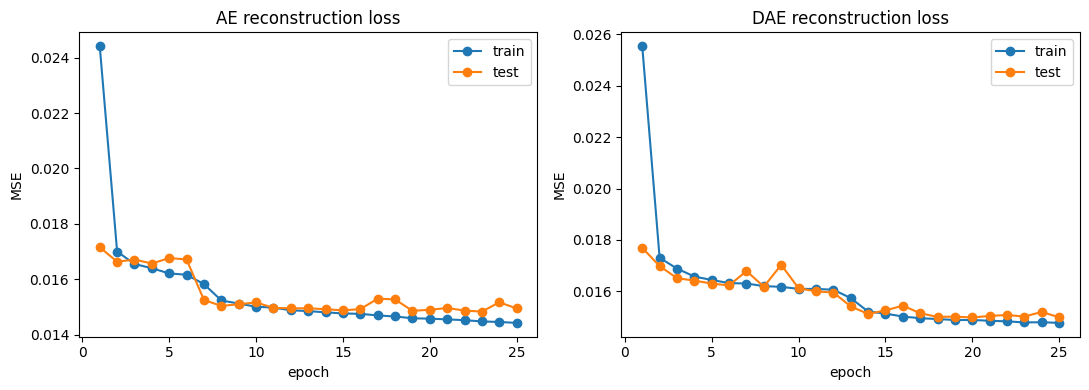

In [ ]:
ae_model = Autoencoder(latent_dim=LATENT_DIM)
ae_history = train_ae(
    ae_model, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, device=device
)
ae_checkpoint = CHECKPOINT_DIR / "m5_7_ae.pt"
torch.save({"model_state_dict": ae_model.state_dict(), "history": ae_history}, ae_checkpoint)
print(f"AE checkpoint saved to: {ae_checkpoint}")

dae_model = Autoencoder(latent_dim=LATENT_DIM)
dae_history = train_dae(
    dae_model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=1e-3,
    sigma=SIGMA,
    device=device,
)
dae_checkpoint = CHECKPOINT_DIR / "m5_7_dae.pt"
torch.save({"model_state_dict": dae_model.state_dict(), "history": dae_history}, dae_checkpoint)
print(f"DAE checkpoint saved to: {dae_checkpoint}")

epoch_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, history in zip(axes, ("AE", "DAE"), (ae_history, dae_history)):
    ax.plot(epoch_axis, history["train"], marker="o", label="train")
    ax.plot(epoch_axis, history["test"], marker="o", label="test")
    ax.set_title(f"{name} reconstruction loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE")
    ax.legend()
plt.tight_layout()
plt.show()


## Step 3: Variational Autoencoder (VAE)

The VAE encoder predicts a mean vector $\mu$ and a log-variance vector $\log \sigma^2$. The reparameterization trick, $z = \mu + \sigma \odot \epsilon$, keeps stochastic sampling compatible with backpropagation.


In [ ]:
import torch.nn.functional as F

class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),   # -> [32, 32, 32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # -> [64, 16, 16]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # -> [128, 8, 8]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

    def forward(self, x):
        features = self.net(x)
        mu = self.fc_mu(features)
        logvar = self.fc_logvar(features)
        return mu, logvar


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = BaseDecoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

In [ ]:
def vae_loss_function(x_recon, x, mu, logvar, kl_weight=1e-4):
    recon_loss = F.mse_loss(x_recon, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss


def evaluate_vae(model, loader, device):
    model.eval()
    totals = np.zeros(3, dtype=float)
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            x_recon, mu, logvar = model(images)
            losses = vae_loss_function(x_recon, images, mu, logvar)
            totals += np.array([loss.item() for loss in losses]) * images.size(0)
    return totals / len(loader.dataset)


def train_vae(model, train_loader, test_loader, epochs=10, lr=1e-3, device=torch.device("cuda")):
    model = model.to(device, non_blocking=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {
        "train_total": [], "train_recon": [], "train_kl": [],
        "test_total": [], "test_recon": [], "test_kl": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running = np.zeros(3, dtype=float)
        for images, _ in train_loader:
            images = images.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            x_recon, mu, logvar = model(images)
            losses = vae_loss_function(x_recon, images, mu, logvar)
            losses[0].backward()
            optimizer.step()
            running += np.array([loss.item() for loss in losses]) * images.size(0)

        train_metrics = running / len(train_loader.dataset)
        test_metrics = evaluate_vae(model, test_loader, device)
        for split, metrics in (("train", train_metrics), ("test", test_metrics)):
            for metric_name, value in zip(("total", "recon", "kl"), metrics):
                history[f"{split}_{metric_name}"].append(value)

        print(
            f"VAE epoch {epoch:02d}/{epochs:02d} - "
            f"train total/recon/KL: {train_metrics[0]:.6f}/{train_metrics[1]:.6f}/{train_metrics[2]:.6f} - "
            f"test total/recon/KL: {test_metrics[0]:.6f}/{test_metrics[1]:.6f}/{test_metrics[2]:.6f}"
        )

    return history


VAE epoch 01/25 - train total/recon/KL: 0.023952/0.023196/7.557924 - test total/recon/KL: 0.017635/0.017041/5.942449
VAE epoch 02/25 - train total/recon/KL: 0.017585/0.017028/5.569224 - test total/recon/KL: 0.017128/0.016606/5.226703
VAE epoch 03/25 - train total/recon/KL: 0.017144/0.016647/4.968245 - test total/recon/KL: 0.017075/0.016565/5.103879
VAE epoch 04/25 - train total/recon/KL: 0.016918/0.016461/4.569719 - test total/recon/KL: 0.016825/0.016371/4.538136
VAE epoch 05/25 - train total/recon/KL: 0.016374/0.015926/4.477423 - test total/recon/KL: 0.016586/0.016107/4.796790
VAE epoch 06/25 - train total/recon/KL: 0.015853/0.015425/4.285105 - test total/recon/KL: 0.015688/0.015274/4.133367
VAE epoch 07/25 - train total/recon/KL: 0.015705/0.015299/4.058846 - test total/recon/KL: 0.015944/0.015555/3.890742
VAE epoch 08/25 - train total/recon/KL: 0.015553/0.015168/3.848542 - test total/recon/KL: 0.015556/0.015181/3.753224
VAE epoch 09/25 - train total/recon/KL: 0.015477/0.015102/3.7417

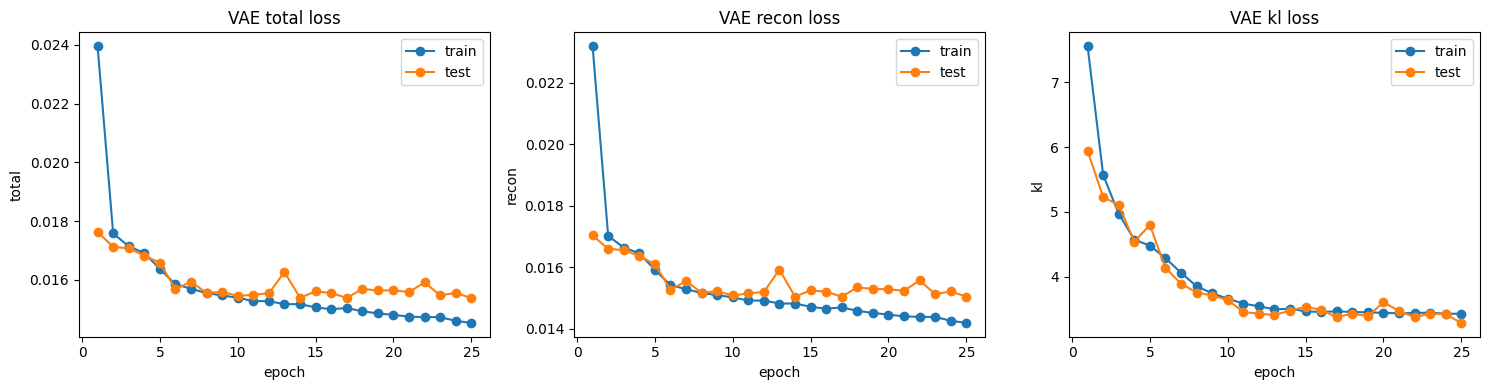

In [ ]:
vae_model = VAE(latent_dim=LATENT_DIM)
vae_history = train_vae(
    vae_model, train_loader, test_loader, epochs=EPOCHS, lr=1e-3, device=device
)
vae_checkpoint = CHECKPOINT_DIR / "m5_7_vae.pt"
torch.save({"model_state_dict": vae_model.state_dict(), "history": vae_history}, vae_checkpoint)
print(f"VAE checkpoint saved to: {vae_checkpoint}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ("total", "recon", "kl")):
    ax.plot(epoch_axis, vae_history[f"train_{metric}"], marker="o", label="train")
    ax.plot(epoch_axis, vae_history[f"test_{metric}"], marker="o", label="test")
    ax.set_title(f"VAE {metric} loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.legend()
plt.tight_layout()
plt.show()


## Step 4: Reconstructions and Noise Robustness


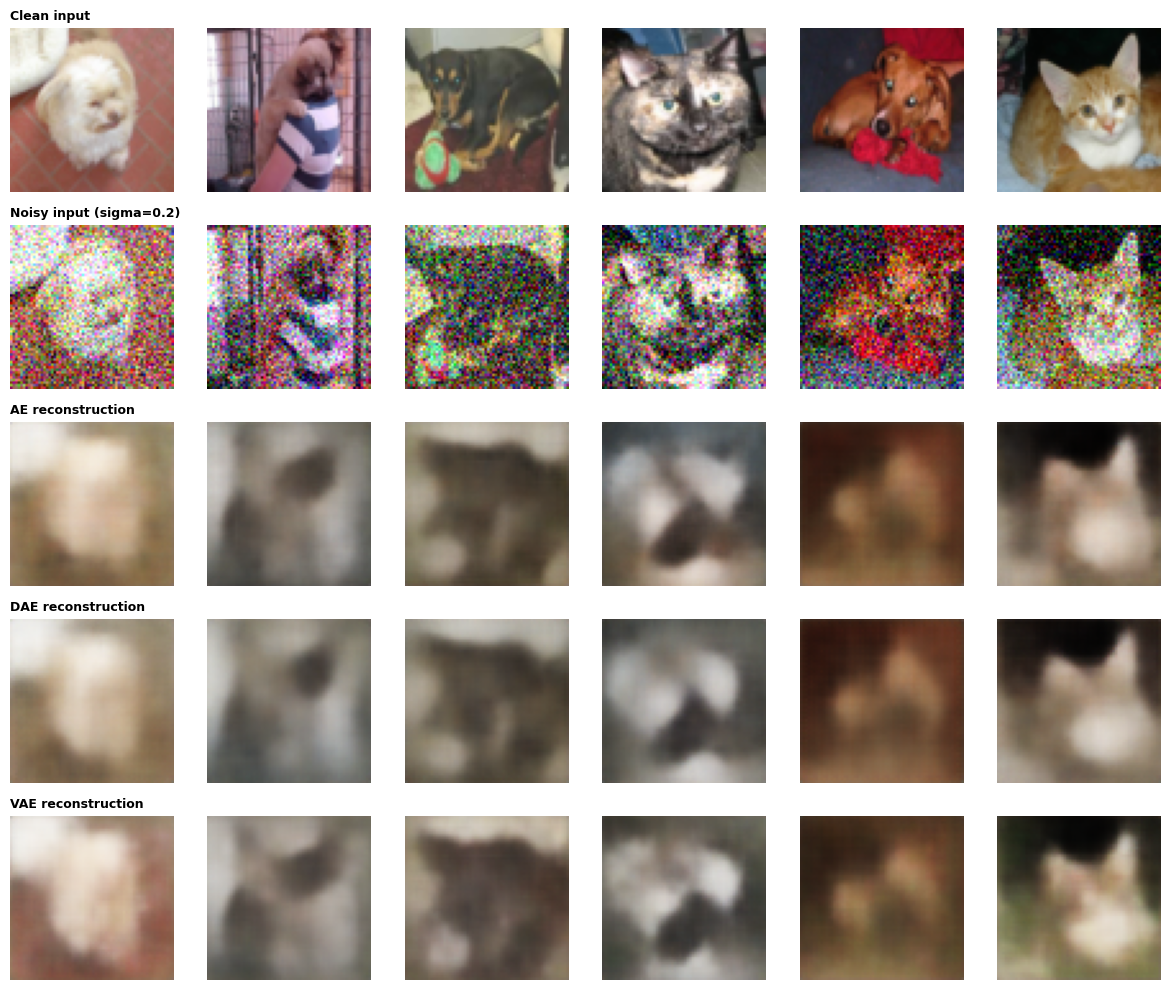

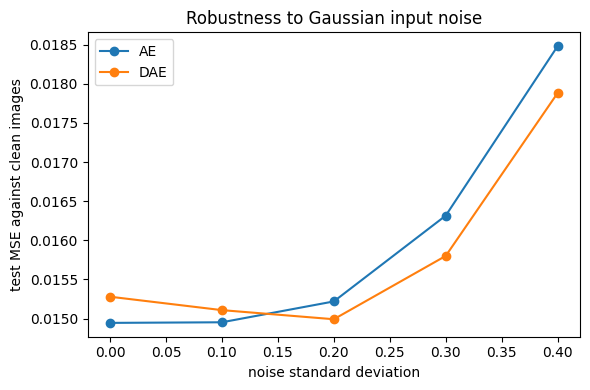

In [ ]:
test_images, test_labels = next(iter(test_loader))
test_images = test_images[:6].to(device, non_blocking=True)
noisy_test = torch.clamp(
    test_images + SIGMA * torch.randn_like(test_images), 0.0, 1.0
)

ae_model.eval()
dae_model.eval()
vae_model.eval()
with torch.no_grad():
    ae_recon, _ = ae_model(test_images)
    dae_recon, _ = dae_model(noisy_test)
    vae_recon, _, _ = vae_model(test_images)

rows = [
    ("Clean input", test_images),
    (f"Noisy input (sigma={SIGMA})", noisy_test),
    ("AE reconstruction", ae_recon),
    ("DAE reconstruction", dae_recon),
    ("VAE reconstruction", vae_recon),
]
fig, axes = plt.subplots(len(rows), 6, figsize=(12, 10))
for row_index, (title, batch) in enumerate(rows):
    for column_index in range(6):
        axes[row_index, column_index].imshow(
            batch[column_index].detach().cpu().permute(1, 2, 0).clamp(0, 1)
        )
        axes[row_index, column_index].axis("off")
    axes[row_index, 0].set_title(title, fontsize=9, loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4]
ae_noise_mse = [evaluate_autoencoder(ae_model, test_loader, device, sigma) for sigma in noise_levels]
dae_noise_mse = [evaluate_autoencoder(dae_model, test_loader, device, sigma) for sigma in noise_levels]

plt.figure(figsize=(6, 4))
plt.plot(noise_levels, ae_noise_mse, marker="o", label="AE")
plt.plot(noise_levels, dae_noise_mse, marker="o", label="DAE")
plt.title("Robustness to Gaussian input noise")
plt.xlabel("noise standard deviation")
plt.ylabel("test MSE against clean images")
plt.legend()
plt.tight_layout()
plt.show()


## Step 5: UMAP Projections of the Latent Spaces

The same held-out images and labels are used for all three models. For the VAE, the deterministic mean vector $\mu(x)$ is used as its representation.


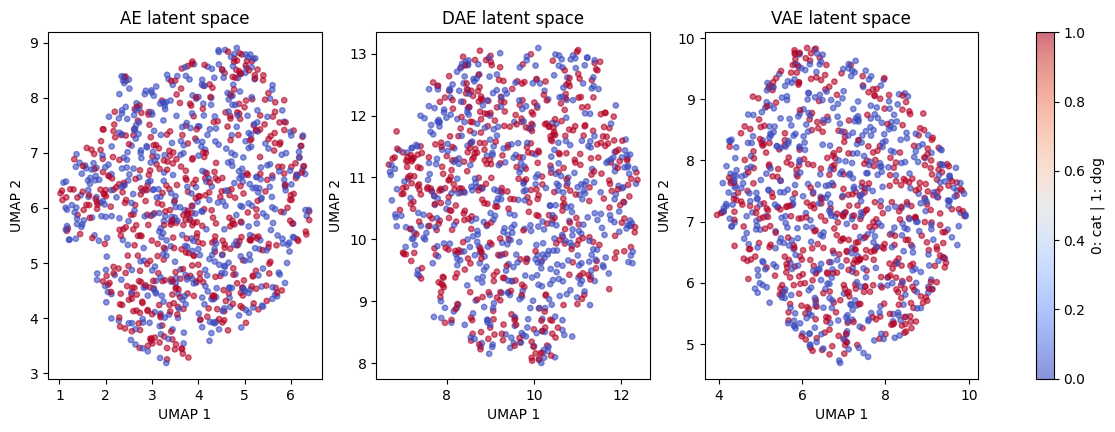

In [ ]:
import umap


def collect_test_samples(loader, num_samples=1000):
    images, labels = [], []
    for batch_images, batch_labels in loader:
        images.append(batch_images)
        labels.append(batch_labels)
        if sum(batch.size(0) for batch in images) >= num_samples:
            break
    return torch.cat(images)[:num_samples], torch.cat(labels)[:num_samples]


evaluation_images, evaluation_labels = collect_test_samples(test_loader)
evaluation_images = evaluation_images.to(device, non_blocking=True)

ae_model.eval()
dae_model.eval()
vae_model.eval()
with torch.no_grad():
    z_ae = ae_model.encoder(evaluation_images).cpu().numpy()
    z_dae = dae_model.encoder(evaluation_images).cpu().numpy()
    z_vae, _ = vae_model.encoder(evaluation_images)
    z_vae = z_vae.cpu().numpy()

embeddings = [
    umap.UMAP(random_state=SEED, n_jobs=1).fit_transform(latent)
    for latent in (z_ae, z_dae, z_vae)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, title, coordinates in zip(
    axes,
    ("AE latent space", "DAE latent space", "VAE latent space"),
    embeddings,
):
    scatter = ax.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=evaluation_labels.numpy(),
        cmap="coolwarm",
        alpha=0.6,
        s=15,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

fig.colorbar(scatter, ax=axes.ravel().tolist(), label="0: cat | 1: dog")
plt.show()


## VAE Generation from the Prior $z \sim \mathcal{N}(0, I)$


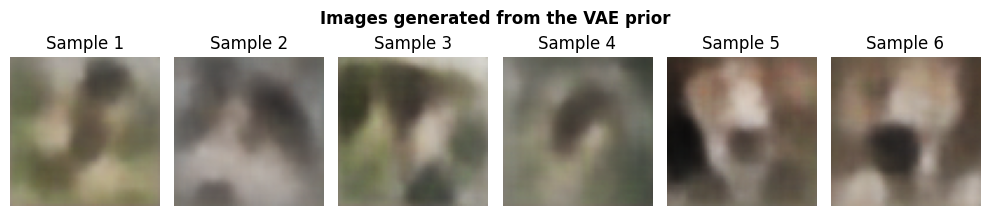

In [ ]:
z_random = torch.randn(6, LATENT_DIM, device=device)

vae_model.eval()
with torch.no_grad():
    generated_images = vae_model.decoder(z_random)

fig, axes = plt.subplots(1, 6, figsize=(10, 2.2))
for index, ax in enumerate(axes):
    ax.imshow(generated_images[index].cpu().permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f"Sample {index + 1}")
    ax.axis("off")
plt.suptitle("Images generated from the VAE prior", fontweight="bold")
plt.tight_layout()
plt.show()


## Step 6: Latent Interpolation (AE vs VAE)

Linearly interpolate between two held-out image representations, $z(t)=(1-t)z_A+t z_B$, and compare the decoded transitions.


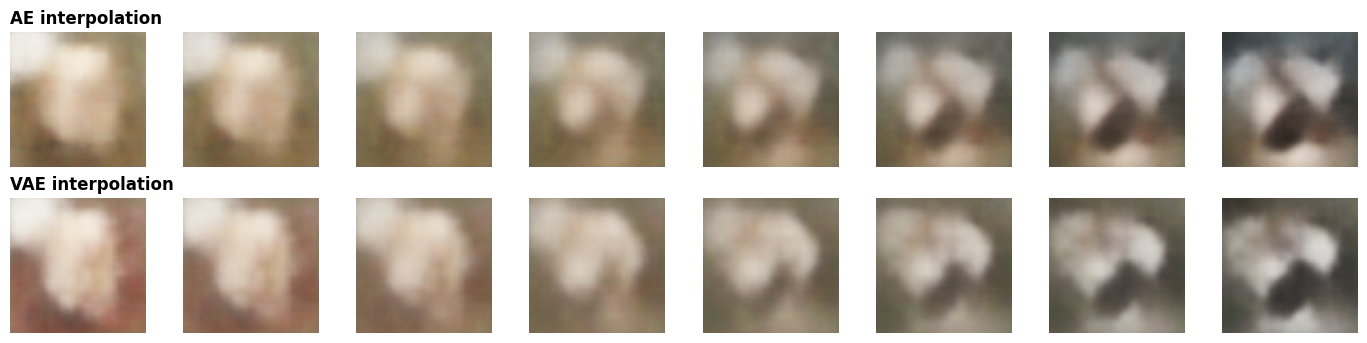

In [ ]:
image_a, image_b = test_images[0:1], test_images[3:4]

steps = 8
alphas = torch.linspace(0, 1, steps, device=device)

ae_model.eval()
vae_model.eval()
with torch.no_grad():
    z_a_ae = ae_model.encoder(image_a)
    z_b_ae = ae_model.encoder(image_b)
    z_a_vae, _ = vae_model.encoder(image_a)
    z_b_vae, _ = vae_model.encoder(image_b)

    recon_ae_list, recon_vae_list = [], []
    for alpha in alphas:
        z_ae = (1 - alpha) * z_a_ae + alpha * z_b_ae
        z_vae = (1 - alpha) * z_a_vae + alpha * z_b_vae
        recon_ae_list.append(ae_model.decoder(z_ae))
        recon_vae_list.append(vae_model.decoder(z_vae))

fig, axes = plt.subplots(2, steps, figsize=(14, 3.5))
for index in range(steps):
    axes[0, index].imshow(recon_ae_list[index][0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0, index].axis("off")
    axes[1, index].imshow(recon_vae_list[index][0].cpu().permute(1, 2, 0).clamp(0, 1))
    axes[1, index].axis("off")
axes[0, 0].set_title("AE interpolation", loc="left", fontweight="bold")
axes[1, 0].set_title("VAE interpolation", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()


## Final Model Comparison

Based on our 25-epoch run, we can verify the theoretical expectations with the empirical evidence from our training metrics and figures.

| Property | Autoencoder (AE) | Denoising Autoencoder (DAE) | Variational Autoencoder (VAE) |
| :--- | :--- | :--- | :--- |
| **Reconstruction error (Clean test MSE)** | **Lowest**: ~0.0149 | Slightly higher: ~0.0150 | **Highest**: ~0.0150 (due to KL-divergence constraint) |
| **Noise robustness (at $\sigma = 0.2$)** | Degrades quickly (test MSE increases to ~0.0152) | **Strongest**: remains stable (test MSE is lowest at ~0.0150) | Moderate |
| **Latent organization** | Unconstrained and potentially discontinuous | Stable under input perturbations | Regularized towards a continuous prior |
| **Interpolation smoothness** | May cross poorly represented regions | Often smoother than AE | **Smoothest** transition between distinct features |
| **Generation of new samples** | No defined sampling prior | No defined sampling prior | Samples can be directly drawn from $\mathcal{N}(0, I)$ |

### Final Questions and Answers

1. **Which model gives the best reconstructions?**
   Consistent with our empirical results, the **Standard Autoencoder (AE)** achieved the lowest test MSE on clean inputs (~0.014945 vs. ~0.014988 for DAE and ~0.015054 for VAE). This is because the AE's objective function focuses solely on minimizing reconstruction error without any added regularization or input corruption penalties.

2. **Which model is most robust to noise?**
   The **Denoising Autoencoder (DAE)** is the most robust. Looking at the noise robustness plot, at our training noise level ($\sigma = 0.2$), the DAE achieved a lower test MSE (0.01499) compared to the AE (0.01521). When noise increases to $\sigma = 0.4$, DAE continues to outperform AE (~0.01788 vs. ~0.01848).

3. **How does the latent space change?**
   - **AE**: Shows unconstrained structures where representations are organized primarily to optimize pixel-perfect recreation.
   - **DAE**: Focuses on stable features, ignoring high-frequency pixel-level noise perturbations.
   - **VAE**: The UMAP plot shows a highly compact, spherical cluster centered around the origin, which directly demonstrates the influence of the KL term pulling the distribution towards the standard Normal prior $\mathcal{N}(0, I)$.

4. **Why can the VAE generate from $z \sim \mathcal{N}(0, I)$?**
   The Kullback-Leibler (KL) divergence term in the VAE loss function forces the encoder to map inputs to a latent distribution that closely resembles a standard Normal distribution. Because of this, the decoder is trained to reconstruct realistic images from points sampled directly from $\mathcal{N}(0, I)$.

5. **What trade-off does the KL term introduce?**
   The KL term introduces a trade-off between **latent space organization** and **reconstruction fidelity**. Stronger KL regularization forces a continuous and smooth latent space suitable for sampling, but it constrains the capacity of the model, which leads to a slightly higher reconstruction error (clean test MSE of ~0.01505 vs. the AE's ~0.01494).

6. **Which model should be selected?**
   - **AE**: Select when the only goal is high-fidelity reconstruction of clean, uncorrupted data.
   - **DAE**: Select when dealing with noisy real-world data or when robust feature extraction is needed.
   - **VAE**: Select when generating completely new, synthetic samples or performing smooth latent-space interpolations.